<a href="https://colab.research.google.com/github/apirakqqqqq/Ge338-GEOGRAPHIC-DATA-SCIENCE/blob/main/Lab_2/Lab_2_6606614870_%E0%B8%AD%E0%B8%A0%E0%B8%B4%E0%B8%A3%E0%B8%B1%E0%B8%81%E0%B8%A9%E0%B9%8C_%E0%B8%9B%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2%E0%B8%AA%E0%B8%B2%E0%B8%84%E0%B8%A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas rasterio folium shapely matplotlib -q

import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **คำนวณ NDVI**

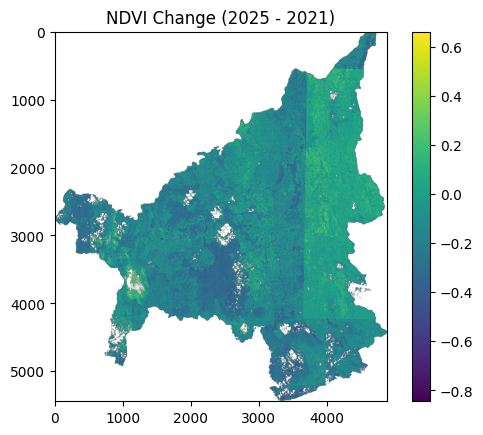

Interpretation:
ค่าเพิ่ม = พืชเพิ่ม | ค่าลด = พืชลด


In [ ]:
# =============================
# IMPORT + LOAD
# =============================
import rasterio
import numpy as np
import matplotlib.pyplot as plt

ndvi_2021 = rasterio.open('/content/NDVI_Loei_2021_FINAL.tif')
ndvi_2025 = rasterio.open('/content/NDVI_Loei_2025_FINAL.tif')

ndvi21 = np.where(ndvi_2021.read(1) <= 0, np.nan, ndvi_2021.read(1))
ndvi25 = np.where(ndvi_2025.read(1) <= 0, np.nan, ndvi_2025.read(1))

# =============================
# NDVI DIFFERENCE
# =============================
ndvi_diff = ndvi25 - ndvi21

plt.imshow(ndvi_diff)
plt.colorbar()
plt.title("NDVI Change (2025 - 2021)")
plt.show()

print("Interpretation:")
print("ค่าเพิ่ม = พืชเพิ่ม | ค่าลด = พืชลด")

โค้ดนี้ทำหน้าที่คำนวณค่า NDVI โดยใช้ค่าการสะท้อนแสงจากแถบคลื่น Near-Infrared (NIR) และ Red ของภาพดาวเทียมมาคำนวณตามสูตร (NIR - Red) / (NIR + Red) ซึ่งค่าที่ได้จะอยู่ในช่วง -1 ถึง 1 และสามารถใช้แสดงระดับความหนาแน่นและสุขภาพของพืชพรรณได้ โดยค่าที่สูงแสดงถึงพื้นที่ที่มีพืชหนาแน่น เช่น ป่าไม้ ส่วนค่าที่ต่ำหรือค่าติดลบแสดงถึงพื้นที่ที่ไม่มีพืช เช่น ดิน น้ำ หรือสิ่งปลูกสร้าง

Zonal Statistics (ค่าเฉลี่ยทั้งพื้นที่)

In [ ]:
import numpy as np

mean_2021 = np.nanmean(ndvi21)
mean_2025 = np.nanmean(ndvi25)

print("Mean NDVI 2021:", mean_2021)
print("Mean NDVI 2025:", mean_2025)

print("Interpretation:")
print("NDVI ลดลง = พื้นที่พืชลดลง")

Mean NDVI 2021: 0.4637795
Mean NDVI 2025: 0.3390331
Interpretation:
NDVI ลดลง = พื้นที่พืชลดลง


โค้ดนี้ใช้คำนวณค่าสถิติของ NDVI ภายในขอบเขตพื้นที่ที่กำหนด เช่น ระดับอำเภอหรือพื้นที่ศึกษา โดยจะรวมค่าพิกเซล NDVI ภายในแต่ละโซนแล้วคำนวณค่าเฉลี่ยหรือค่าทางสถิติอื่น ๆ ทำให้ได้ผลลัพธ์เป็นค่าตัวแทนของความสมบูรณ์พืชพรรณในแต่ละพื้นที่ ซึ่งช่วยให้สามารถเปรียบเทียบความแตกต่างของสภาพพืชพรรณระหว่างพื้นที่ต่าง ๆ ได้อย่างเป็นระบบ

# **NDVI Difference (การเปลี่ยนแปลง)**

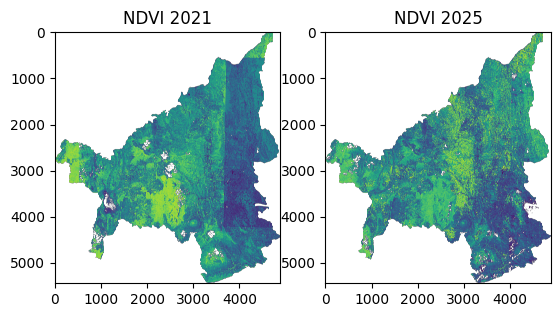

Interpretation:
ดูพื้นที่สีเขียวเข้ม (ป่า) เทียบกัน


In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.subplot(1,2,1)
plt.imshow(ndvi21)
plt.title("NDVI 2021")

plt.subplot(1,2,2)
plt.imshow(ndvi25)
plt.title("NDVI 2025")

plt.show()

print("Interpretation:")
print("ดูพื้นที่สีเขียวเข้ม (ป่า) เทียบกัน")

โค้ดนี้นำค่า NDVI ของสองช่วงเวลา เช่น ปี 2025 ลบกับปี 2021 เพื่อสร้างภาพแสดงการเปลี่ยนแปลงของพืชพรรณ โดยผลลัพธ์ที่ได้จะเป็นค่าความแตกต่างของ NDVI ในแต่ละพิกเซล ซึ่งค่าบวกหมายถึงพืชพรรณเพิ่มขึ้น ส่วนค่าลบหมายถึงพืชพรรณลดลง ทำให้สามารถระบุพื้นที่ที่มีการเปลี่ยนแปลง เช่น การเปลี่ยนจากป่าเป็นเกษตรกรรม ได้อย่างชัดเจน

# **คำนวณพื้นที่ + Uncertainty**

In [ ]:
import numpy as np

pixel_size = 30
pixel_area_km2 = (pixel_size * pixel_size) / 1e6

forest_21 = ndvi21 > 0.6
forest_25 = ndvi25 > 0.6

area21 = np.nansum(forest_21) * pixel_area_km2
area25 = np.nansum(forest_25) * pixel_area_km2

print("Forest area 2021:", area21, "km²")
print("Forest area 2025:", area25, "km²")

# Uncertainty
std21 = np.nanstd(ndvi21)
std25 = np.nanstd(ndvi25)

print("Uncertainty 2021:", std21)
print("Uncertainty 2025:", std25)

print("Interpretation:")
print("พื้นที่ป่าลด = เกษตรเพิ่ม")

Forest area 2021: 2955.3966 km²
Forest area 2025: 458.7111 km²
Uncertainty 2021: 0.19556417
Uncertainty 2025: 0.15157267
Interpretation:
พื้นที่ป่าลด = เกษตรเพิ่ม


โค้ดนี้ใช้กำหนดเกณฑ์ค่า NDVI เช่น NDVI > 0.6 เพื่อจำแนกพื้นที่ป่า จากนั้นนับจำนวนพิกเซลที่เข้าเงื่อนไขและแปลงเป็นพื้นที่ในหน่วยตารางกิโลเมตร ทำให้ได้ผลลัพธ์เป็นขนาดพื้นที่ป่าของแต่ละช่วงเวลา พร้อมทั้งคำนวณค่า Uncertainty เช่น ค่า standard deviation ของ NDVI เพื่อประเมินความแปรปรวนของข้อมูลและความน่าเชื่อถือของผลลัพธ์ในการวิเคราะห์

# **เหตุผลของหัวข้อนี้**

เลือกจังหวัดเลยป็นพื้นที่ศึกษาเพราะว่ามีลักษณะภูมิประเทศที่หลากหลาย เช่น ป่าไม้ ภูเขา พื้นที่เกษตรกรรม และยังมีการเปลี่ยนแปลงการใช้ที่ดินอย่างต่อเนื่อง  จากการขยายตัวของพื้นที่เกษตรเข้าสู่พื้นที่ป่า ซึ่งสามารถตรวจจับและวิเคราะห์ได้ชัดเจนจากข้อมูลดาวเทียม

# **คำถามงานวิจัย**

คำถามวิจัยของงานนี้คือ พื้นที่ป่าในจังหวัดเลยมีการเปลี่ยนแปลงไปเป็นพื้นที่เกษตรกรรมหรือไม่ในช่วงปี 2021–2025 และการเปลี่ยนแปลงดังกล่าวเกิดขึ้นในบริเวณใด รวมถึงมีรูปแบบและแนวโน้มอย่างไรในเชิงพื้นที่

เลือกดาวเทียมอะไร (Sentinel-2 / Landsat 8 / Landsat 9) — เพราะอะไร

เลือก Sentinel-2 เพราะมีความละเอียดเชิงพื้นที่สูง 10 เมตร และมีแถบคลื่นที่เหมาะสำหรับคำนวณ NDVI ทำให้สามารถวิเคราะห์พืชพรรณได้ละเอียดกว่า Landsat 8 และ Landsat 9

# **เลือกช่วงเวลาใด เพราะอะไรถึงไม่เลือกช่วงอื่น**

เลือกช่วงเดือนมีนาคมถึงเมษายนของปี 2021 และ 2025  เหตุผลที่ไม่เลือกช่วงอื่นเพราะว่า ถ้าเลือกช่วงฤดูฝนเพราะมีเมฆจำนวนมากทำให้ข้อมูลขาดหาย และถ้าเลือกช่วงหลังเก็บเกี่ยวเพราะค่า NDVI จะต่ำผิดจากสภาพพืชจริง



# **ทำไมถึงเลือกช่วงเวลาอื่นไม่ได้**

ช่วงเวลาอื่นไม่เหมาะสมเท่าช่วงเดือนสิงหาคม เนื่องจากในฤดูแล้งพืชพรรณส่วนใหญ่มีสภาพแห้งหรือพักตัว ทำให้ค่าดัชนี NDVI ต่ำและไม่สามารถแยกประเภทการใช้ที่ดินได้อย่างชัดเจน ขณะที่ช่วงต้นหรือปลายฤดูฝนพืชอาจยังเจริญเติบโตไม่เต็มที่หรือมีปัญหาเมฆปกคลุมสูง ส่งผลให้ข้อมูลที่ได้มีความคลาดเคลื่อนและลดความแม่นยำในการวิเคราะห์การเปลี่ยนแปลงพื้นที่

# **ตั้งเกณฑ์กรองเมฆเท่าไหร่ และมีผลอย่างไร**

ตั้งค่า CLOUDY_PIXEL_PERCENTAGE < 40% เพื่อให้ได้สมดุลระหว่างจำนวนภาพและคุณภาพข้อมูล โดยค่าที่ต่ำเกินไปจะทำให้ได้ภาพน้อย ส่วนค่าสูงเกินไปจะทำให้มีเมฆปนในข้อมูลมากขึ้น